In [1]:
import pandas as pd
import seaborn as sns

from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score

In [2]:
# Configuration of display 
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 7
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['lines.linewidth'] = 0.6

# Color palettes for clusters
palette_gmm={0: '#326a81a0' , 1: '#7876b1a0', 2: '#9fbccaa0', 3: '#cccccca0'}
palette_pam={1: '#326a81a0' , 3: '#7876b1a0', 2: '#9fbccaa0', 0: '#cccccca0'}

In [3]:
# Load distance matrix and ordination results
dmat = pd.read_csv("data/2-processed/amplicon/diversity/beta_distance/weighted_unifrac_distance/distance-matrix.tsv", index_col=0, header=0, sep="\t")
pcoa = pd.read_csv("data/2-processed/amplicon/diversity/pcoa/weighted_unifrac/ordination.txt", index_col=0, sep="\t", skiprows=9, header=None, skipfooter=3)

# Load the clustering results from GMM
cl_gmm = pd.read_csv('data/3-results/enterotype/tsne_cluster.tsv', sep='\t', header=0, index_col=0)

/tmp/ipykernel_1774837/1871513916.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  pcoa = pd.read_csv("data/2-processed/amplicon/diversity/pcoa/weighted_unifrac/ordination.txt", index_col=0, sep="\t", skiprows=9, header=None, skipfooter=3)


In [4]:
# Evaluate silhouette scores for different numbers of clusters
for k in range(2, 11):
    model = KMedoids(
        n_clusters=k,
        metric="precomputed",
        method="pam"
    )
    model.fit(dmat)
    labels = model.labels_
    score = silhouette_score(dmat, labels, metric='precomputed')
    print(f"Silhouette score for k={k}: {score:.4f}")

Silhouette score for k=2: 0.1645
Silhouette score for k=3: 0.1982
Silhouette score for k=4: 0.1751
Silhouette score for k=5: 0.1747
Silhouette score for k=6: 0.1509
Silhouette score for k=7: 0.1374
Silhouette score for k=8: 0.1262
Silhouette score for k=9: 0.0990
Silhouette score for k=10: 0.0863


In [5]:
# Clustering with KMedoids using the optimal number of clusters (k=4)
model = KMedoids(
    n_clusters=4,
    metric="precomputed",
    method="pam"
)

labels = model.fit_predict(dmat)
cl_pam = pd.DataFrame(labels, index=dmat.index, columns=["cluster"])

In [6]:
# Cluster mapping for GMM and PAM results
cmap_gmm = {}
for id, row in cl_gmm.iterrows():
    cl = int(row['cluster'])
    if cl not in cmap_gmm:
        cmap_gmm[cl] = []
    cmap_gmm[cl].append(id)

cmap_pam = {}
for id, row in cl_pam.iterrows():
    cl = int(row['cluster'])
    if cl not in cmap_pam:
        cmap_pam[cl] = []
    cmap_pam[cl].append(id)

In [7]:
# Compare clusters between GMM and PAM
results = []
for id1 in cmap_gmm.keys():
    for id2 in cmap_pam.keys():
        c = set(cmap_gmm[id1]).intersection(set(cmap_pam[id2]))
        n1 = len(cmap_gmm[id1])
        n2 = len(cmap_pam[id2])
        print(f'Cluster {id1} (n={n1}) vs Cluster {id2} (n={n2}): {len(c)} shared samples ({len(c)/n1:.2%}, {len(c)/n2:.2%})')            
        
        results.append({
            'ori': id1,
            'new': id2,
            'n_ori': n1,
            'n_gen': n2,
            'n_shared': len(c),
            'shared_ratio_ori': len(c)/n1,
            'shared_ratio_gen': len(c)/n2
        })

results_df = pd.DataFrame(results)
table = results_df.pivot(index='ori', columns='new', values='n_shared')
table.index = ['Bif+Faec-low', 'Prev', 'Phoc', 'Faec+Blau']

Cluster 3 (n=122) vs Cluster 0 (n=219): 107 shared samples (87.70%, 48.86%)
Cluster 3 (n=122) vs Cluster 3 (n=59): 0 shared samples (0.00%, 0.00%)
Cluster 3 (n=122) vs Cluster 2 (n=98): 4 shared samples (3.28%, 4.08%)
Cluster 3 (n=122) vs Cluster 1 (n=107): 11 shared samples (9.02%, 10.28%)
Cluster 1 (n=80) vs Cluster 0 (n=219): 20 shared samples (25.00%, 9.13%)
Cluster 1 (n=80) vs Cluster 3 (n=59): 59 shared samples (73.75%, 100.00%)
Cluster 1 (n=80) vs Cluster 2 (n=98): 0 shared samples (0.00%, 0.00%)
Cluster 1 (n=80) vs Cluster 1 (n=107): 1 shared samples (1.25%, 0.93%)
Cluster 2 (n=186) vs Cluster 0 (n=219): 83 shared samples (44.62%, 37.90%)
Cluster 2 (n=186) vs Cluster 3 (n=59): 0 shared samples (0.00%, 0.00%)
Cluster 2 (n=186) vs Cluster 2 (n=98): 89 shared samples (47.85%, 90.82%)
Cluster 2 (n=186) vs Cluster 1 (n=107): 14 shared samples (7.53%, 13.08%)
Cluster 0 (n=95) vs Cluster 0 (n=219): 9 shared samples (9.47%, 4.11%)
Cluster 0 (n=95) vs Cluster 3 (n=59): 0 shared samples 

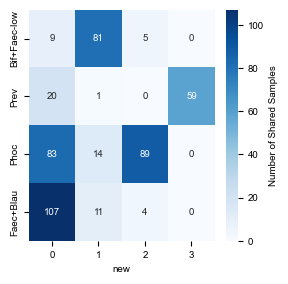

In [8]:
# Display the heatmap of shared samples between GMM and PAM clusters
fig, ax = plt.subplots(figsize=(3, 3))
sns.heatmap(table, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Number of Shared Samples'}, ax=ax)

fig.savefig('figures/clustering_pam/comparison_of_clusters.pdf', bbox_inches='tight', dpi=300)

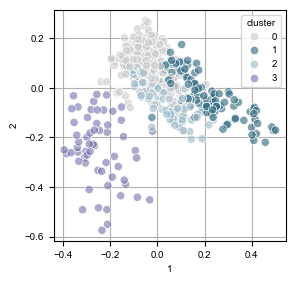

In [9]:
# Display the PCoA scatter plot with clusters from PAM
fig, ax = plt.subplots(figsize=(3, 3))
sns.scatterplot(data=pcoa.iloc[:, 0:2], x=pcoa.columns[0], y=pcoa.columns[1], hue=cl_pam['cluster'], palette=palette_pam, legend='full', ax=ax, zorder=10)
ax.grid(zorder=0)
fig.savefig('figures/clustering_pam/pcoa_pam.pdf', bbox_inches='tight', dpi=300)

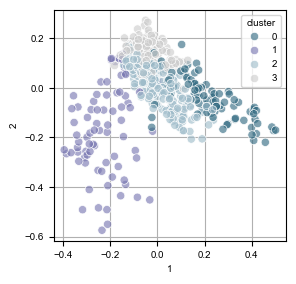

In [10]:
# Display the PCoA scatter plot with clusters from GMM
fig, ax = plt.subplots(figsize=(3, 3))
sns.scatterplot(data=pcoa.iloc[:, 0:2], x=pcoa.columns[0], y=pcoa.columns[1], hue=cl_gmm['cluster'], palette=palette_gmm, legend='full', ax=ax, zorder=10)
ax.grid(zorder=0)
fig.savefig('figures/clustering_pam/pcoa_gmm.pdf', bbox_inches='tight', dpi=300)

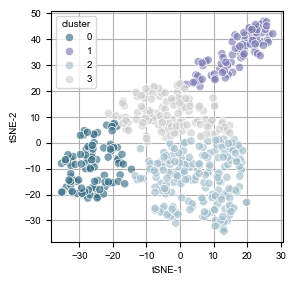

In [11]:
# Display the t-SNE scatter plot with clusters from GMM
fig, ax = plt.subplots(figsize=(3, 3))
sns.scatterplot(data=cl_gmm, x='tSNE-1', y='tSNE-2', hue=cl_gmm['cluster'], palette=palette_gmm, legend='full', ax=ax, zorder=10)
ax.grid(zorder=0)
fig.savefig('figures/clustering_pam/tsne_gmm.pdf', bbox_inches='tight', dpi=300)

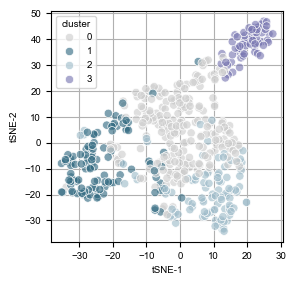

In [12]:
# Display the t-SNE scatter plot with clusters from PAM
fig, ax = plt.subplots(figsize=(3, 3))
sns.scatterplot(data=cl_gmm, x='tSNE-1', y='tSNE-2', hue=cl_pam['cluster'], palette=palette_pam, legend='full', ax=ax, zorder=10)
ax.grid(zorder=0)
fig.savefig('figures/clustering_pam/tsne_pam.pdf', bbox_inches='tight', dpi=300)